Import Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

Load Dataset

In [ ]:
df = pd.read_csv("traffic_accidents.csv")

Dataset Overview

In [ ]:
print("Shape:", df.shape)

df.head()

Shape: (209306, 24)


,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,07/29/2023 01:00:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,13,7,7
1,08/13/2023 12:11:00 AM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0,1,8
2,12/09/2021 10:30:00 AM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,10,5,12
3,08/09/2023 07:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,NONINCAPACITATING INJURY,5.0,0.0,0.0,5.0,0.0,0.0,19,4,8
4,08/19/2023 02:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,14,7,8


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209306 entries, 0 to 209305
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   crash_date                     209306 non-null  object 
 1   traffic_control_device         209306 non-null  object 
 2   weather_condition              209306 non-null  object 
 3   lighting_condition             209306 non-null  object 
 4   first_crash_type               209306 non-null  object 
 5   trafficway_type                209306 non-null  object 
 6   alignment                      209306 non-null  object 
 7   roadway_surface_cond           209306 non-null  object 
 8   road_defect                    209306 non-null  object 
 9   crash_type                     209306 non-null  object 
 10  intersection_related_i         209306 non-null  object 
 11  damage                         209306 non-null  object 
 12  prim_contributory_cause       

In [ ]:
df.describe()

,num_units,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
count,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000
mean,2.063300,0.382717,0.001859,0.038102,0.221241,0.121516,2.244002,13.373047,4.144024,6.771822
std,0.396012,0.799720,0.047502,0.233964,0.614960,0.450865,1.241175,5.603830,1.966864,3.427593
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,9.000000,2.000000,4.000000
50%,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,14.000000,4.000000,7.000000
75%,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,3.000000,17.000000,6.000000,10.000000
max,11.000000,21.000000,3.000000,7.000000,21.000000,15.000000,49.000000,23.000000,7.000000,12.000000


Check Missing Values

In [ ]:
df.isnull().sum()

,0
crash_date,0
traffic_control_device,0
weather_condition,0
lighting_condition,0
first_crash_type,0
trafficway_type,0
alignment,0
roadway_surface_cond,0
road_defect,0
crash_type,0


Fill Missing Values

In [ ]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

print("Missing Values Handled")

/tmp/ipykernel_1353/2805415686.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


Missing Values Handled


/tmp/ipykernel_1353/2805415686.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


Accident Analysis

Weather Conditions

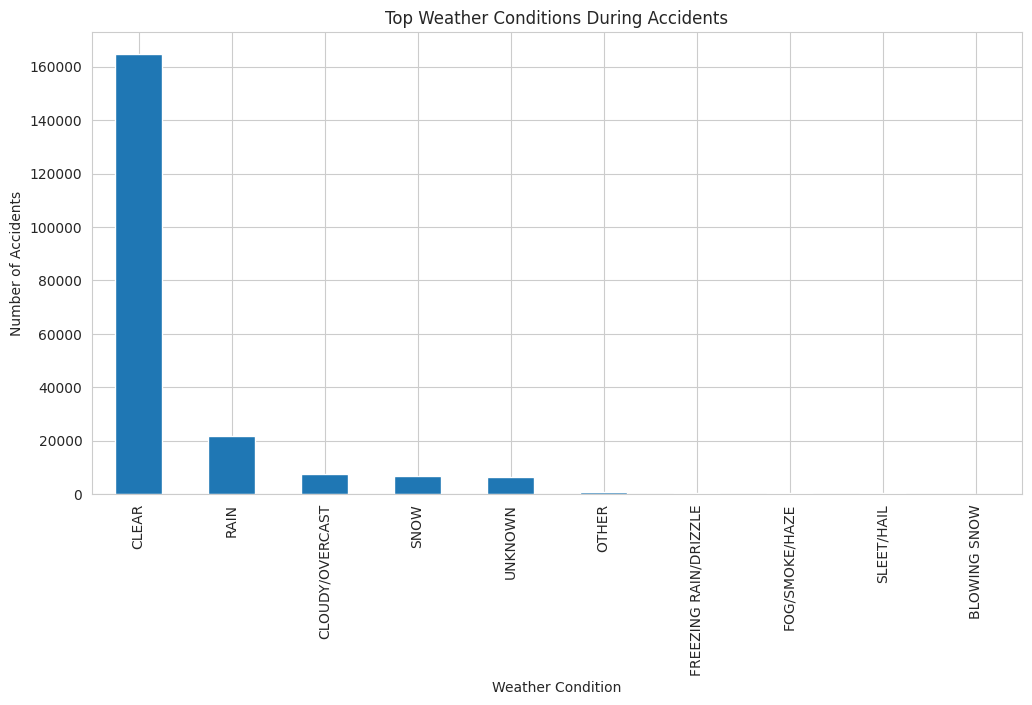

In [ ]:
plt.figure(figsize=(12,6))

df['weather_condition'].value_counts().head(10).plot(kind='bar')

plt.title("Top Weather Conditions During Accidents")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Accidents")

plt.show()

Road Surface Condition

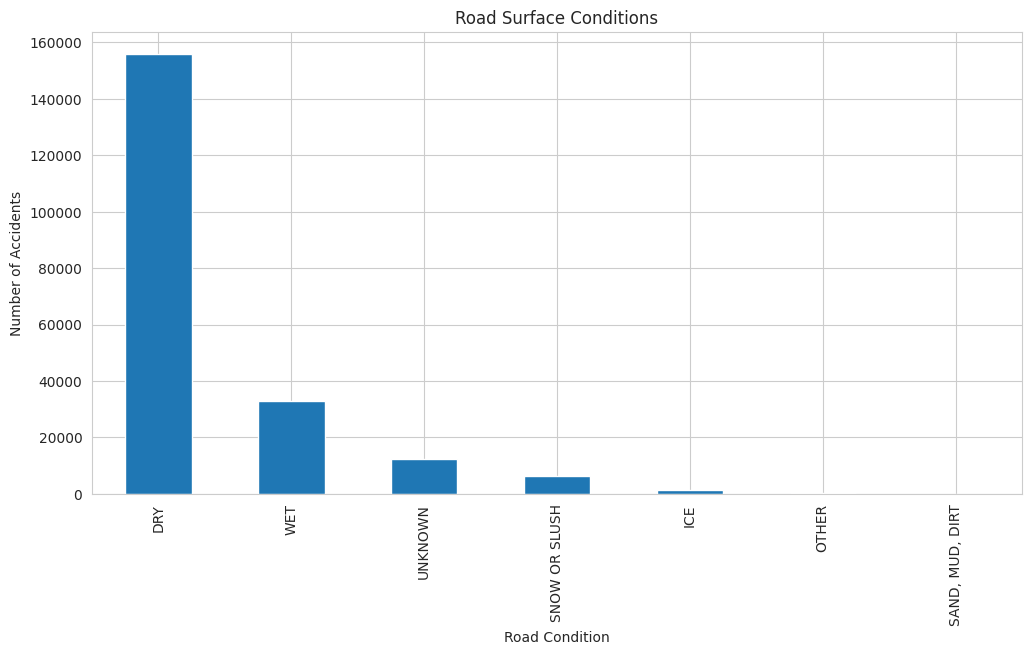

In [ ]:
plt.figure(figsize=(12,6))

df['roadway_surface_cond'].value_counts().head(10).plot(kind='bar')

plt.title("Road Surface Conditions")
plt.xlabel("Road Condition")
plt.ylabel("Number of Accidents")

plt.show()

Lighting Condition

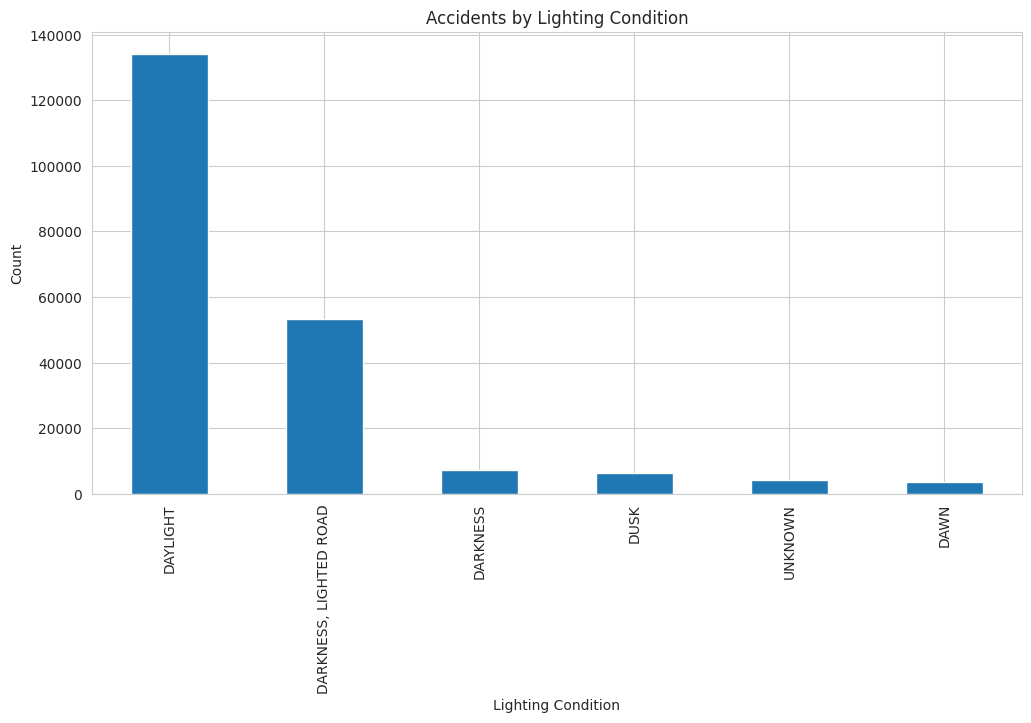

In [ ]:
plt.figure(figsize=(12,6))

df['lighting_condition'].value_counts().plot(kind='bar')

plt.title("Accidents by Lighting Condition")
plt.xlabel("Lighting Condition")
plt.ylabel("Count")

plt.show()

Accidents by Hour

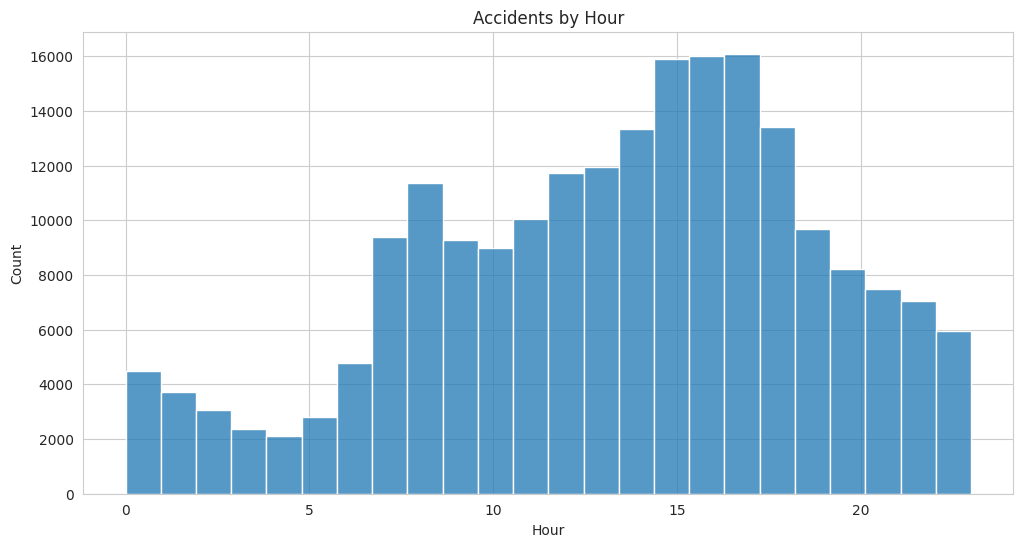

In [ ]:
plt.figure(figsize=(12,6))

sns.histplot(df['crash_hour'], bins=24)

plt.title("Accidents by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")

plt.show()

Accidents by Day of Week

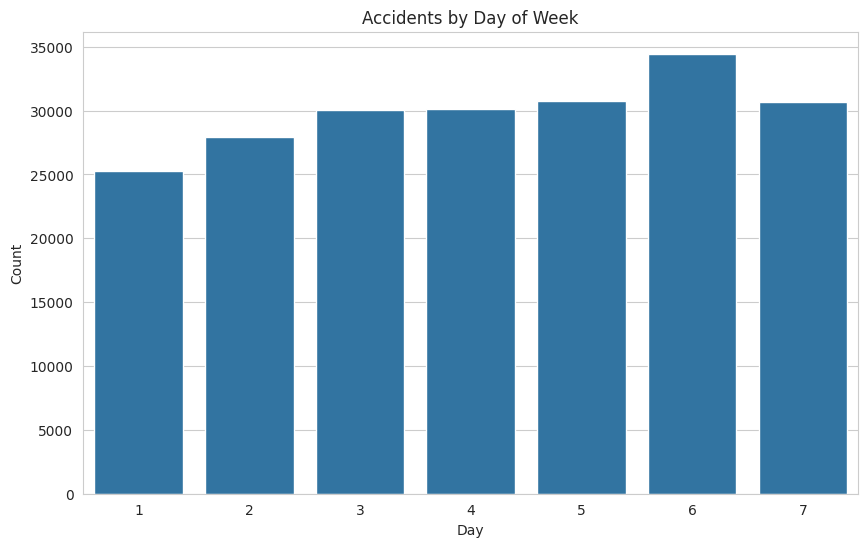

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(x='crash_day_of_week', data=df)

plt.title("Accidents by Day of Week")
plt.xlabel("Day")
plt.ylabel("Count")

plt.show()

Accidents by Month

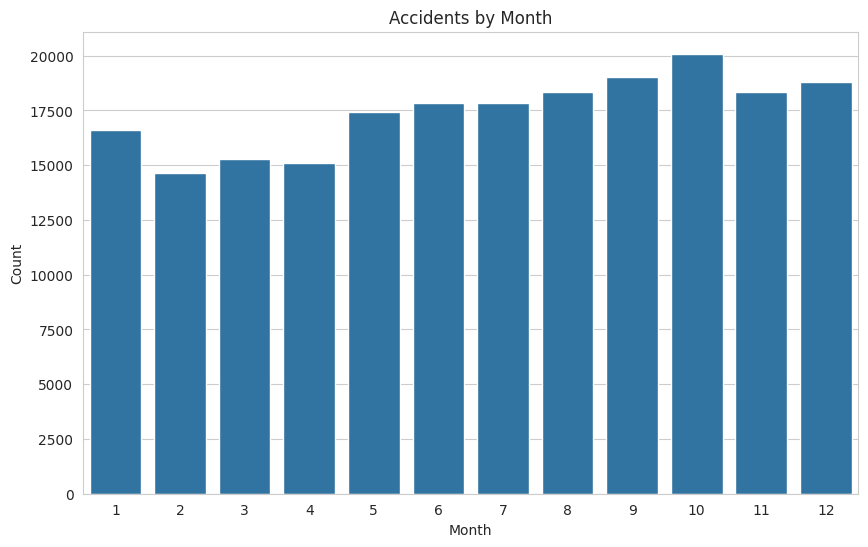

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(x='crash_month', data=df)

plt.title("Accidents by Month")
plt.xlabel("Month")
plt.ylabel("Count")

plt.show()

Primary Causes of Accidents

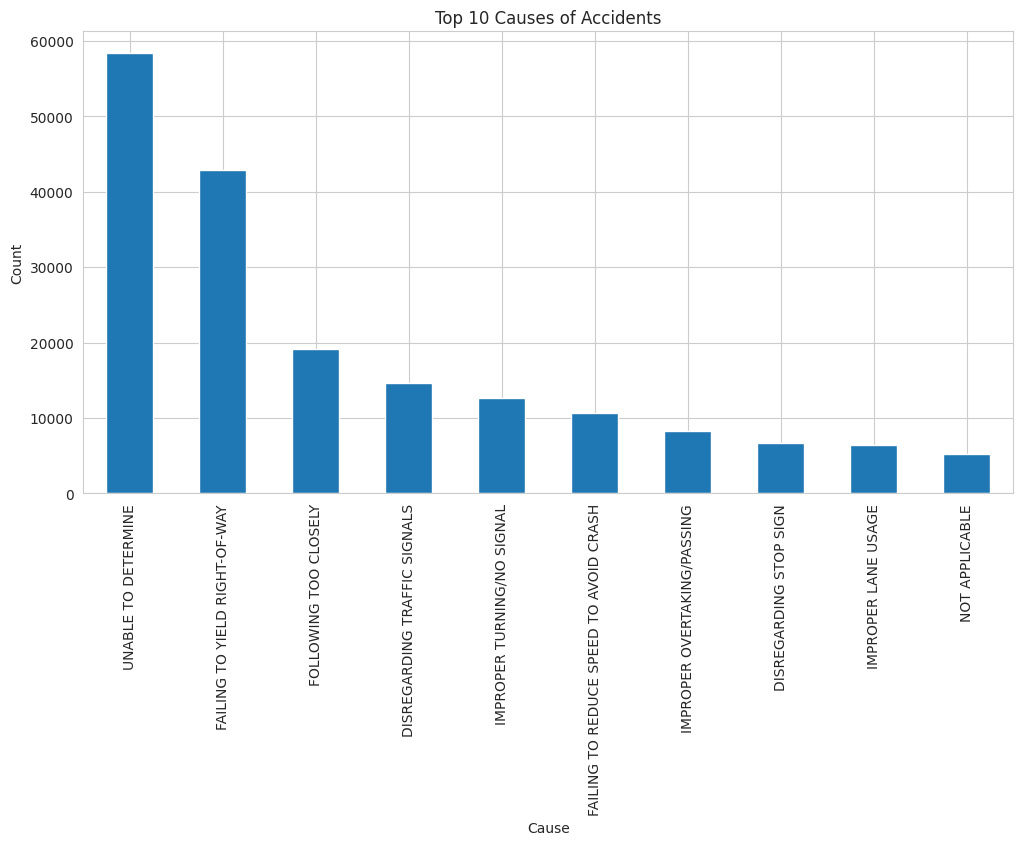

In [ ]:
plt.figure(figsize=(12,6))

df['prim_contributory_cause'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Causes of Accidents")
plt.xlabel("Cause")
plt.ylabel("Count")

plt.show()

Most Severe Injury

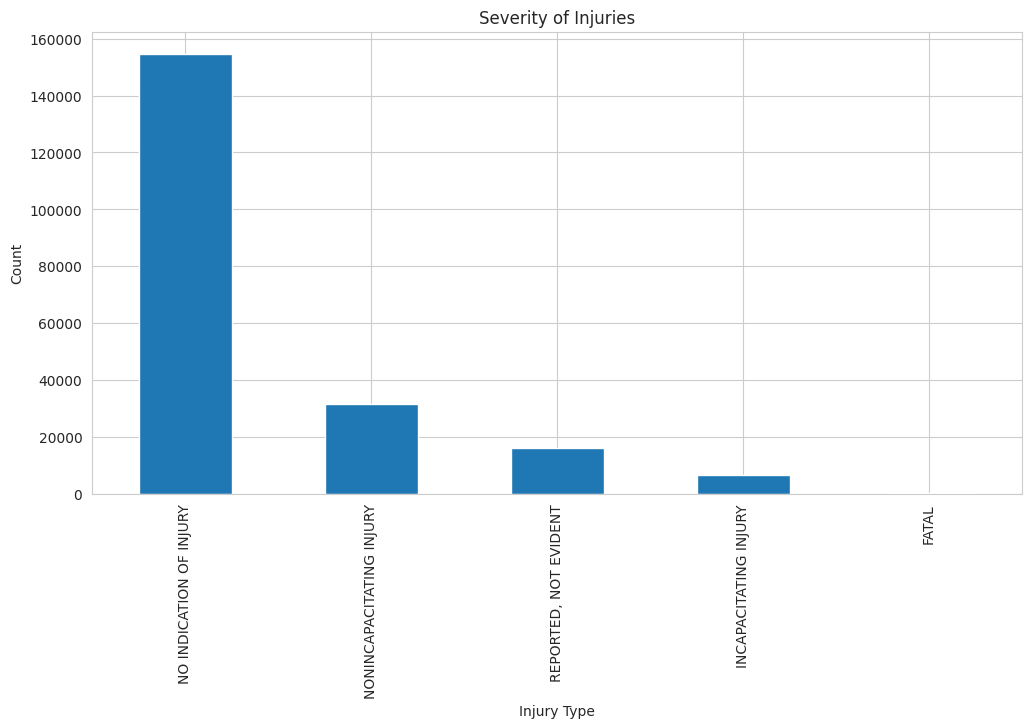

In [ ]:
plt.figure(figsize=(12,6))

df['most_severe_injury'].value_counts().plot(kind='bar')

plt.title("Severity of Injuries")
plt.xlabel("Injury Type")
plt.ylabel("Count")

plt.show()

Crash Type Analysis

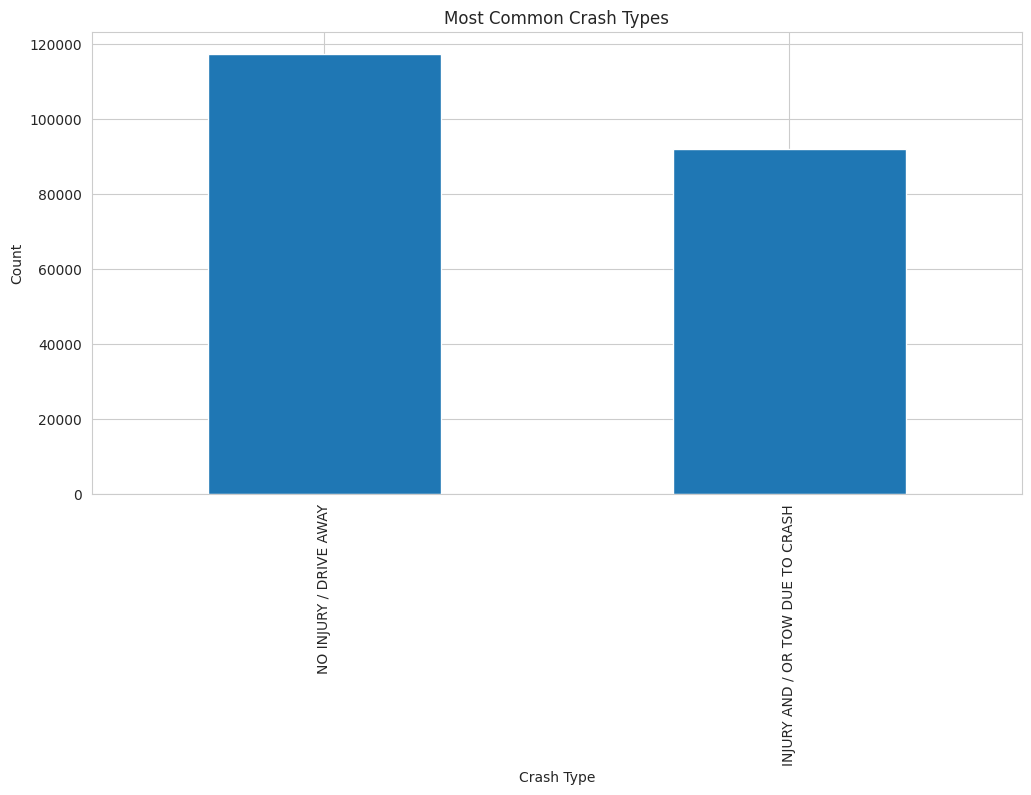

In [ ]:
plt.figure(figsize=(12,6))

df['crash_type'].value_counts().head(10).plot(kind='bar')

plt.title("Most Common Crash Types")
plt.xlabel("Crash Type")
plt.ylabel("Count")

plt.show()

Correlation Heatmap

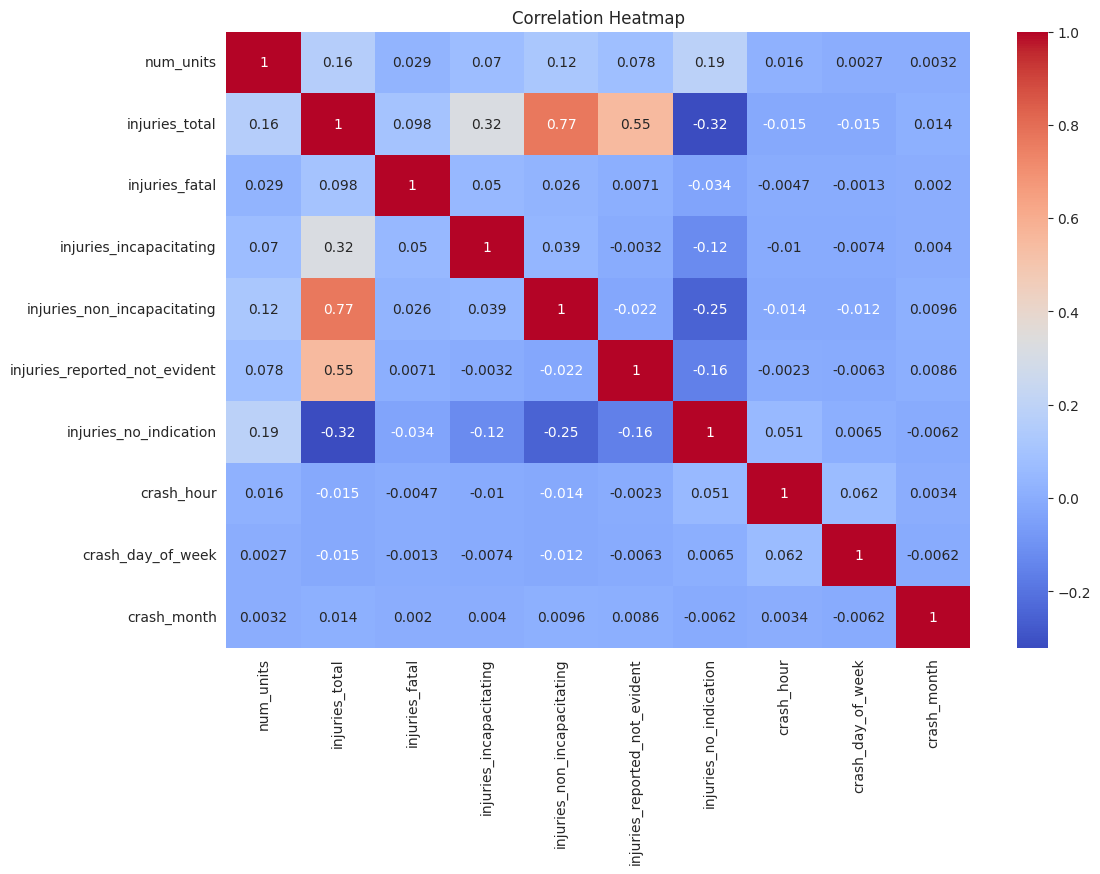

In [ ]:
numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

Insights Section

In [ ]:
print("Most Common Weather Condition:")
print(df['weather_condition'].mode()[0])

print("\nMost Common Road Condition:")
print(df['roadway_surface_cond'].mode()[0])

print("\nPeak Accident Hour:")
print(df['crash_hour'].mode()[0])

print("\nTop Cause:")
print(df['prim_contributory_cause'].mode()[0])

print("\nMost Severe Injury Category:")
print(df['most_severe_injury'].mode()[0])

Most Common Weather Condition:
CLEAR

Most Common Road Condition:
DRY

Peak Accident Hour:
17

Top Cause:
UNABLE TO DETERMINE

Most Severe Injury Category:
NO INDICATION OF INJURY


Save Cleaned Dataset

In [ ]:
df.to_csv("cleaned_traffic_accidents.csv", index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully
